# DSCI 552 — Homework 3
**Seonmin Kim**

Time Series Classification Part 1: Feature Creation/Extraction (AReM), plus ISLR 3.7.4.

## 1(a) Load the AReM data

In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/AReM")

df = pd.read_csv(DATA_DIR / "bending1" / "dataset1.csv", comment="#", header=None,
                )
df.head()

,0,1,2,3,4,5,6
0,0,39.25,0.43,22.75,0.43,33.75,1.3
1,250,39.25,0.43,23.00,0.00,33.00,0.0
2,500,39.25,0.43,23.25,0.43,33.00,0.0
3,750,39.50,0.50,23.00,0.71,33.00,0.0
4,1000,39.50,0.50,24.00,0.00,33.00,0.0


In [2]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/AReM")

COLS = ["time", "avg_rss12", "var_rss12", "avg_rss13", "var_rss13", "avg_rss23", "var_rss23"]

df = pd.read_csv(DATA_DIR / "bending1" / "dataset1.csv", comment="#", header=None,
                 names=COLS)
df.head()

,time,avg_rss12,var_rss12,avg_rss13,var_rss13,avg_rss23,var_rss23
0,0,39.25,0.43,22.75,0.43,33.75,1.3
1,250,39.25,0.43,23.00,0.00,33.00,0.0
2,500,39.25,0.43,23.25,0.43,33.00,0.0
3,750,39.50,0.50,23.00,0.71,33.00,0.0
4,1000,39.50,0.50,24.00,0.00,33.00,0.0


In [3]:
#df_bad = pd.read_csv(DATA_DIR / "bending2" / "dataset4.csv", comment="#", header=None,names=COLS)

df_bad = pd.read_csv(DATA_DIR / "bending2" / "dataset4.csv", comment="#", 
                     header=None,names=COLS,
                    sep = r"[,\s]+", engine="python")

df_bad.head()


,time,avg_rss12,var_rss12,avg_rss13,var_rss13,avg_rss23,var_rss23
0,0,32.50,0.50,0.0,0.0,19.0,1.00
1,250,32.50,0.50,0.0,0.0,18.5,0.50
2,500,32.75,0.43,1.0,0.0,18.0,0.00
3,750,32.50,0.50,0.0,0.0,17.5,0.50
4,1000,32.50,0.50,7.5,0.5,17.5,0.87


In [4]:
#df_bad = pd.read_csv(DATA_DIR / "bending2" / "dataset4.csv", comment="#", header=None,names=COLS)

df_bad = pd.read_csv(DATA_DIR / "cycling" / "dataset9.csv", comment="#", 
                     header=None,names=range(8),
                    sep = r"[,\s]+", engine="python")

df_bad.head()


,0,1,2,3,4,5,6,7
0,0,41.67,0.47,17.67,2.87,14.50,2.06,NaN
1,250,42.00,2.12,9.67,6.34,14.75,2.49,NaN
2,500,35.75,1.79,13.75,3.03,18.50,4.09,NaN
3,750,34.25,4.02,17.75,1.09,16.25,3.70,NaN
4,1000,36.50,4.33,14.75,1.09,12.67,4.92,NaN


In [5]:
def load_instance(path):
    df = pd.read_csv(path, comment="#", header=None,
                     sep=r"[,\s]+", engine="python",
                     names=range(8))          
    df = df.dropna(axis=1, how="all")         
    df = df.iloc[:, 1:7]                      
    df.columns = COLS[1:]                     
    return df.astype(float)


ACTIVITIES = ["bending1", "bending2", "cycling", "lying", "sitting", "standing", "walking"]

instances = []

for act in ACTIVITIES:
    for f in sorted((DATA_DIR / act).glob("*.csv")):
        num = int(f.stem.replace("dataset", ""))   # "dataset10" → 10

        data = load_instance(f)
        instances.append({"activity": act, "num": num, "data": data})
        

print(len(instances))


88


## 1(b) Train/test split

In [6]:

def is_test(inst):
    if inst["activity"] in ("bending1", "bending2"):
        return inst["num"] in (1,2)
    return inst["num"] in (1,2,3)

test = [i for i in instances if is_test(i)]
train = [i for i in instances if not is_test(i)]

print(len(train), len(test))

69 19


## 1(c)i Time-domain features commonly used in time series classification

Commonly used time-domain features for time series classification include:

- Minimum / Maximum
- Mean, Median
- Standard deviation, Variance
- First and third quartiles, Interquartile range (IQR)
- Range (max - min), Peak-to-peak amplitude
- Skewness, Kurtosis
- Root mean square (RMS)
- Zero-crossing rate
- Autocorrelation coefficients

## 1(c)ii Feature extraction

In [7]:
def extract_features(ts_df):
    out = {}
    for k, col in enumerate(ts_df.columns, start=1):  
        s = ts_df[col]                                  
        out[f"min{k}"]       = s.min()
        out[f"max{k}"]       = s.max()
        out[f"mean{k}"]      = s.mean()
        out[f"median{k}"]    = s.median()
        out[f"std{k}"]       = s.std()
        out[f"1st_quart{k}"] = s.quantile(0.25)
        out[f"3rd_quart{k}"] = s.quantile(0.75)
    return out


print(extract_features(instances[2]["data"]))
print(instances[0].keys())           # dict_keys(['activity', 'num', 'data'])
print(instances[0]["activity"])      # 'bending1'
print(instances[0]["data"].head())
      

{'min1': np.float64(35.0), 'max1': np.float64(47.4), 'mean1': np.float64(43.9545), 'median1': np.float64(44.33), 'std1': np.float64(1.5588350663530308), '1st_quart1': np.float64(43.0), '3rd_quart1': np.float64(45.0), 'min2': np.float64(0.0), 'max2': np.float64(1.7), 'mean2': np.float64(0.4262500000000001), 'median2': np.float64(0.47), 'std2': np.float64(0.33869037350107317), '1st_quart2': np.float64(0.0), '3rd_quart2': np.float64(0.5), 'min3': np.float64(6.5), 'max3': np.float64(29.75), 'mean3': np.float64(22.122354166666664), 'median3': np.float64(23.0), 'std3': np.float64(3.0309428037022643), '1st_quart3': np.float64(19.75), '3rd_quart3': np.float64(24.0), 'min4': np.float64(0.0), 'max4': np.float64(4.44), 'mean4': np.float64(0.49731249999999994), 'median4': np.float64(0.43), 'std4': np.float64(0.5506572901546093), '1st_quart4': np.float64(0.0), '3rd_quart4': np.float64(0.83), 'min5': np.float64(29.0), 'max5': np.float64(38.5), 'mean5': np.float64(35.58845833333333), 'median5': np.fl

In [8]:
feature_df = pd.DataFrame([extract_features(i["data"]) for i in instances])

feature_df["activity"] = [i["activity"] for i in instances]   

feature_df.index = range(1, len(feature_df) + 1)              
feature_df.index.name = "Instance"

print(feature_df.shape)
feature_df

(88, 43)


,min1,max1,mean1,median1,std1,1st_quart1,3rd_quart1,min2,max2,mean2,...,1st_quart5,3rd_quart5,min6,max6,mean6,median6,std6,1st_quart6,3rd_quart6,activity
Instance,,,,,,,,,,,,,,,,,,,,,
1,37.25,45.00,40.624792,40.500,1.476967,39.25,42.0000,0.0,1.30,0.358604,...,33.0000,36.00,0.0,1.92,0.570583,0.430,0.582915,0.00,1.3000,bending1
2,38.00,45.67,42.812812,42.500,1.435550,42.00,43.6700,0.0,1.22,0.372437,...,32.0000,34.50,0.0,3.11,0.571083,0.430,0.601010,0.00,1.3000,bending1
3,35.00,47.40,43.954500,44.330,1.558835,43.00,45.0000,0.0,1.70,0.426250,...,35.3625,36.50,0.0,1.79,0.493292,0.430,0.513506,0.00,0.9400,bending1
4,33.00,47.75,42.179812,43.500,3.670666,39.15,45.0000,0.0,3.00,0.696042,...,30.4575,36.33,0.0,2.18,0.613521,0.500,0.524317,0.00,1.0000,bending1
5,33.00,45.75,41.678063,41.750,2.243490,41.33,42.7500,0.0,2.83,0.535979,...,28.4575,31.25,0.0,1.79,0.383292,0.430,0.389164,0.00,0.5000,bending1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,20.75,46.25,34.763333,35.290,4.742208,31.67,38.2500,0.0,12.68,4.223792,...,14.2500,18.33,0.0,9.39,3.288271,3.270,1.647528,2.05,4.3050,walking
85,21.50,51.00,34.935812,35.500,4.645944,32.00,38.0625,0.0,12.21,4.115750,...,14.2375,18.25,0.0,10.21,3.280021,3.015,1.700918,2.12,4.5000,walking
86,18.33,47.67,34.333042,34.750,4.948770,31.25,38.0000,0.0,12.48,4.396958,...,13.7500,18.00,0.0,8.01,3.261583,2.980,1.617290,2.05,4.3200,walking


## 1(c)iii Standard deviation of each feature + 90% bootstrap confidence interval

In [9]:
import numpy as np
rng = np.random.default_rng(42)   

def bootstrap_ci_std(values, n_boot=1000):
    stds = []
    for _ in range(n_boot):
        
        sample = rng.choice(values, size=len(values), replace=True)  
        stds.append(sample.std(ddof=1))                              
        
    return np.percentile(stds, 5), np.percentile(stds, 95) 


v = feature_df["mean1"].to_numpy()
print(v.std(ddof=1))
print(bootstrap_ci_std(v))


5.3357176583441746
(np.float64(4.684706661825963), np.float64(5.851161699924293))


The mean1 values of the 88 instances are spread out by about ±5.3 around their average."

In [10]:
rows = []

for col in feature_df.columns.drop("activity"):      
    
    v = feature_df[col].to_numpy()
    lo, hi = bootstrap_ci_std(v)
    
    rows.append({"feature": col, "std": v.std(ddof=1), 
                 "CI_lower": lo, "CI_upper": hi})

std_ci = pd.DataFrame(rows).set_index("feature")
std_ci

,std,CI_lower,CI_upper
feature,,,
min1,9.569975,8.291196,10.728164
max1,4.394362,3.327682,5.278264
mean1,5.335718,4.684179,5.861129
median1,5.440054,4.802408,6.059840
std1,1.772153,1.570778,1.953394
1st_quart1,6.153590,5.596156,6.671645
3rd_quart1,5.138925,4.336397,5.831694
min2,0.000000,0.000000,0.000000
max2,5.062729,4.648111,5.406115


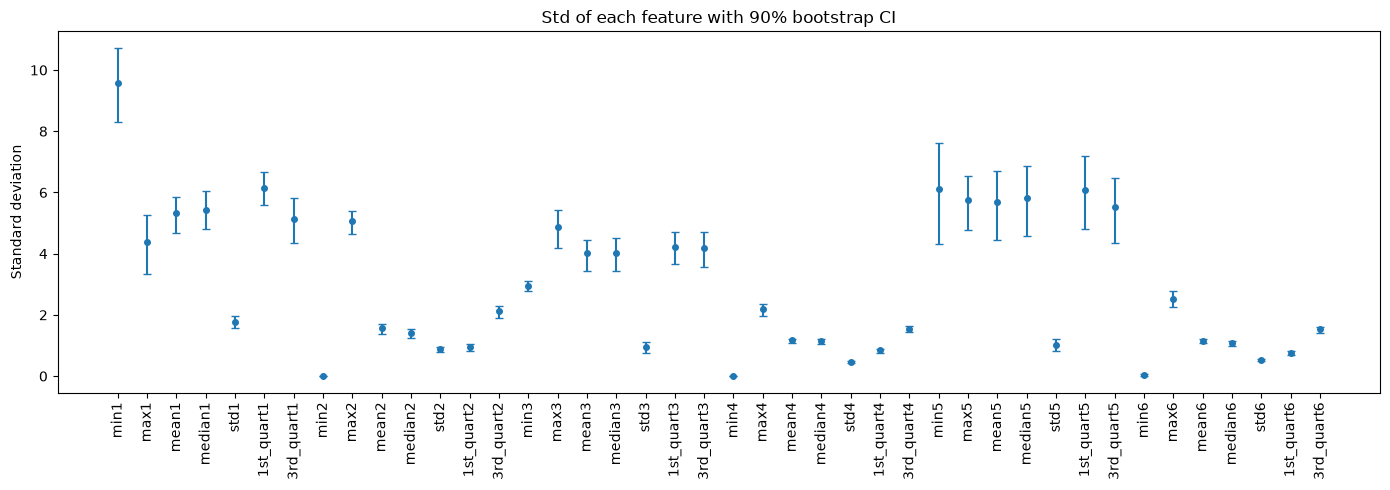

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(std_ci))
ax.errorbar(x, std_ci["std"],
            yerr=[std_ci["std"] - std_ci["CI_lower"], std_ci["CI_upper"] - std_ci["std"]],
            fmt="o", ms=4, capsize=3)
ax.set_xticks(x)
ax.set_xticklabels(std_ci.index, rotation=90)
ax.set_ylabel("Standard deviation")
ax.set_title("Std of each feature with 90% bootstrap CI")
plt.tight_layout()
plt.show()

## 1(c)iv The three most important time-domain features

Based on the standard deviations and their bootstrap confidence intervals above,
the features that vary the most across instances are the **minimum, mean, and
maximum** of each series.

- **Mean** captures the overall RSS level, which differs clearly between static
  postures (lying, sitting, standing) and dynamic activities (walking, cycling).
- **Min / Max** capture the extremes of the signal; dynamic activities swing much
  wider than static ones.
- The median is highly correlated with the mean, and Q1/Q3 overlap with the
  information in min/max/std, so they add little new information.

**Selected features: min, mean, max.**

## 2. ISLR 3.7.4

**(a)** We expect the **cubic regression's training RSS to be lower**. The cubic
model contains the linear model as a special case (β₂ = β₃ = 0), so with its
extra flexibility it always fits the training data at least as well, chasing
noise to reduce training RSS further.

**(b)** We expect the **linear regression's test RSS to be lower**. Since the true
relationship is linear, the cubic model's extra terms only fit noise in the
training set (overfitting), which hurts its performance on new data.

**(c)** The **cubic regression's training RSS is again lower**, by the same
argument as (a) — this holds regardless of the true relationship.

**(d)** **There is not enough information to tell.** If the true relationship is
only slightly non-linear, the linear model's lower variance may win; if it is
strongly non-linear, the cubic model's lower bias wins. This is the
bias–variance trade-off.